<a href="https://colab.research.google.com/github/isha3456/Isha-/blob/main/Miniproject_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Wedding Dataset
   Guest_Count  Decoration_Cost  Catering_Cost  Total_Expense  Budget_Level
0          100            40000          70000         150000             0
1          120            50000          85000         180000             0
2          150            60000         100000         220000             0
3          180            80000         130000         290000             1
4          200           100000         160000         360000             1
5          220           120000         180000         420000             1
6          250           140000         210000         500000             2
7          280           160000         240000         580000             2
8          300           180000         270000         650000             2
9          350           200000         300000         730000             2

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column           Non

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



========== Prediction Result ==========
Estimated Total Expense : ₹ 291364.58
Budget Level            : Standard
Recommended Wedding Plan: Standard


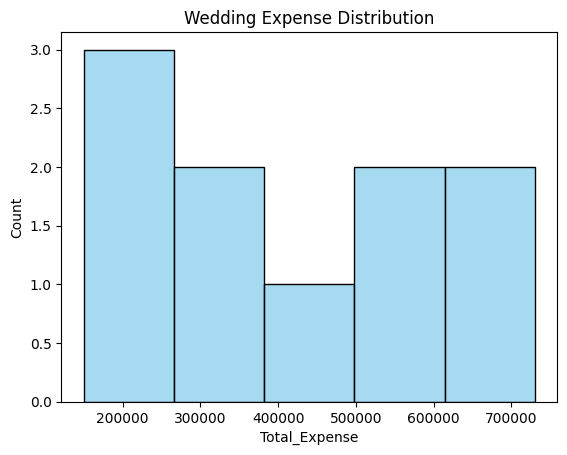

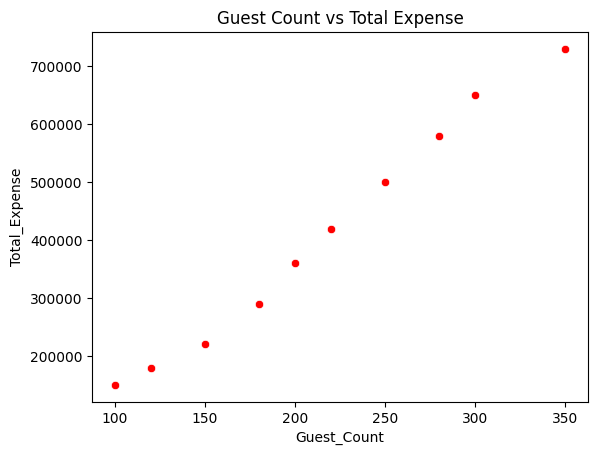

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ---------------- Sample Dataset ----------------
data = {
    "Guest_Count": [100,120,150,180,200,220,250,280,300,350],
    "Decoration_Cost": [40000,50000,60000,80000,100000,120000,140000,160000,180000,200000],
    "Catering_Cost": [70000,85000,100000,130000,160000,180000,210000,240000,270000,300000],
    "Total_Expense": [150000,180000,220000,290000,360000,420000,500000,580000,650000,730000],
    "Budget_Level": [0,0,0,1,1,1,2,2,2,2]    # 0=Budget,1=Standard,2=Luxury
}

df = pd.DataFrame(data)

print("\nWedding Dataset")
print(df)

# ---------------- Data Information ----------------
print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

# ---------------- Features ----------------
X = df[["Guest_Count", "Decoration_Cost", "Catering_Cost"]]

# ---------------- Linear Regression ----------------
lr = LinearRegression()
lr.fit(X, df["Total_Expense"])

# ---------------- Logistic Regression ----------------
log = LogisticRegression(max_iter=1000)
log.fit(X, df["Budget_Level"])

# ---------------- KNN ----------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X, df["Budget_Level"])

# Budget Names
budget = {
    0: "Budget",
    1: "Standard",
    2: "Luxury"
}

# ---------------- User Input ----------------
guest = int(input("\nEnter Guest Count: "))
decoration = int(input("Enter Decoration Cost: "))
catering = int(input("Enter Catering Cost: "))

new_data = np.array([[guest, decoration, catering]])

# ---------------- Predictions ----------------
expense = lr.predict(new_data)
budget_result = log.predict(new_data)[0]
recommend = knn.predict(new_data)[0]

# ---------------- Results ----------------
print("\n========== Prediction Result ==========")
print("Estimated Total Expense : ₹", round(expense[0], 2))
print("Budget Level            :", budget[budget_result])
print("Recommended Wedding Plan:", budget[recommend])

# ---------------- Visualization ----------------

# Expense Distribution
sns.histplot(df["Total_Expense"], bins=5, color="skyblue")
plt.title("Wedding Expense Distribution")
plt.show()

# Guest Count vs Expense
sns.scatterplot(x="Guest_Count", y="Total_Expense", data=df, color="red")
plt.title("Guest Count vs Total Expense")
plt.show()
